In [12]:
import sys
!{sys.executable} -m pip install mysql-connector-python

Defaulting to user installation because normal site-packages is not writeable


In [30]:
import mysql.connector
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mysql.connector import pooling
import warnings

# Suppress UserWarnings (use this approach cautiously)
warnings.filterwarnings('ignore', category=UserWarning)

# Connect to server with explicit settings to avoid warnings
cnx = mysql.connector.connect(
    host="127.0.0.1",
    port=3306,
    user="root",
    password="12345",
    use_pure=True,  # Avoids warnings related to C extension
    auth_plugin='mysql_native_password',  # Explicitly set authentication plugin
    charset='utf8mb4',  # Set character encoding explicitly
    use_unicode=True,
    get_warnings=False  # Suppress server-side warnings
)

In [15]:
query="SELECT * FROM banking_case.Customer"

In [16]:
df=pd.read_sql(query,cnx)

In [17]:
cnx.close()

In [18]:
df.head(5)

,Client ID,Name,Age,Location ID,Joined Bank,Banking Contact,Nationality,Occupation,Fee Structure,Loyalty Classification,...,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
0,IND81288,Raymond Mills,24,34324,06-05-2019,Anthony Torres,American,Safety Technician IV,High,Jade,...,1485828.64,603617.88,607332.46,12249.96,1134475.30,1,2,1,1,1
1,IND65833,Julia Spencer,23,42205,10-12-2001,Jonathan Hawkins,African,Software Consultant,High,Jade,...,641482.79,229521.37,344635.16,61162.31,2000526.10,1,3,2,1,2
2,IND47499,Stephen Murray,27,7314,25-01-2010,Anthony Berry,European,Help Desk Operator,High,Gold,...,1033401.59,652674.69,203054.35,79071.78,548137.58,1,3,3,2,3
3,IND72498,Virginia Garza,40,34594,28-03-2019,Steve Diaz,American,Geologist II,Mid,Silver,...,1048157.49,1048157.49,234685.02,57513.65,1148402.29,0,4,4,1,4
4,IND60181,Melissa Sanders,46,41269,20-07-2012,Shawn Long,American,Assistant Professor,Mid,Platinum,...,487782.53,446644.25,128351.45,30012.14,1674412.12,0,3,1,2,5


In [20]:
df.shape

(3000, 25)

In [21]:
df.describe()

,Age,Location ID,Estimated Income,Superannuation Savings,Amount of Credit Cards,Credit Card Balance,Bank Loans,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03,3000.000000,3.000000e+03,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,51.039667,21563.323000,171305.034263,25531.599673,1.463667,3176.206943,5.913862e+05,6.715602e+05,3.210929e+05,2.329084e+05,29883.529993,8.667598e+05,1.518667,2.249333,2.559333,1.504000,10.425333
std,19.854760,12462.273017,111935.808209,16259.950770,0.676387,2497.094709,4.575570e+05,6.457169e+05,2.820796e+05,2.300078e+05,23109.924010,6.412303e+05,1.102145,1.131191,1.007713,0.500067,5.988242
min,17.000000,12.000000,15919.480000,1482.030000,1.000000,1.170000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,45.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,1.000000
25%,34.000000,10803.500000,82906.595000,12513.775000,1.000000,1236.630000,2.396281e+05,2.044004e+05,1.199475e+05,7.479440e+04,11916.542500,3.748251e+05,1.000000,1.000000,2.000000,1.000000,5.000000
50%,51.000000,21129.500000,142313.480000,22357.355000,1.000000,2560.805000,4.797934e+05,4.633165e+05,2.428157e+05,1.640866e+05,24341.190000,7.113147e+05,2.000000,2.000000,3.000000,2.000000,10.000000
75%,69.000000,32054.500000,242290.305000,35464.740000,2.000000,4522.632500,8.258130e+05,9.427546e+05,4.348749e+05,3.155750e+05,41966.392500,1.185110e+06,2.000000,3.000000,3.000000,2.000000,15.000000
max,85.000000,43369.000000,522330.260000,75963.900000,3.000000,13991.990000,2.667557e+06,3.890598e+06,1.969923e+06,1.724118e+06,124704.870000,3.825962e+06,3.000000,5.000000,4.000000,2.000000,22.000000


In [22]:
df.columns

Index(['Client ID', 'Name', 'Age', 'Location ID', 'Joined Bank',
       'Banking Contact', 'Nationality', 'Occupation', 'Fee Structure',
       'Loyalty Classification', 'Estimated Income', 'Superannuation Savings',
       'Amount of Credit Cards', 'Credit Card Balance', 'Bank Loans',
       'Bank Deposits', 'Checking Accounts', 'Saving Accounts',
       'Foreign Currency Account', 'Business Lending', 'Properties Owned',
       'Risk Weighting', 'BRId', 'GenderId', 'IAId'],
      dtype='object')

In [23]:
df.isnull().sum()

Client ID                   0
Name                        0
Age                         0
Location ID                 0
Joined Bank                 0
Banking Contact             0
Nationality                 0
Occupation                  0
Fee Structure               0
Loyalty Classification      0
Estimated Income            0
Superannuation Savings      0
Amount of Credit Cards      0
Credit Card Balance         0
Bank Loans                  0
Bank Deposits               0
Checking Accounts           0
Saving Accounts             0
Foreign Currency Account    0
Business Lending            0
Properties Owned            0
Risk Weighting              0
BRId                        0
GenderId                    0
IAId                        0
dtype: int64

UNIVARIATE ANALYSIS

<Axes: xlabel='Income Band'>

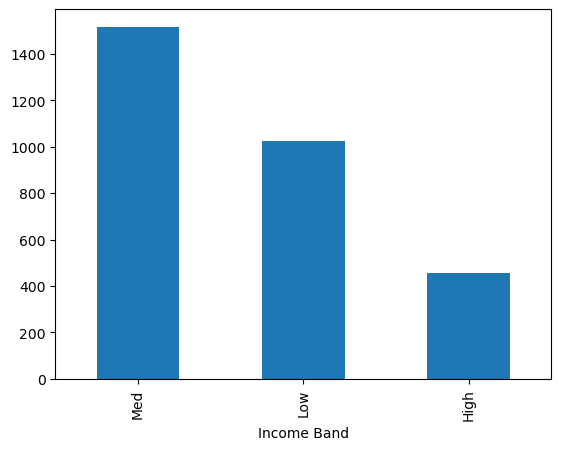

In [27]:
#Coverting income into lables
bins = [0, 100000, 300000, float('inf')]
labels = ['Low', 'Med', 'High']

df['Income Band'] = pd.cut(df['Estimated Income'], bins=bins, labels=labels, right=False)
df['Income Band'].value_counts().plot(kind='bar')

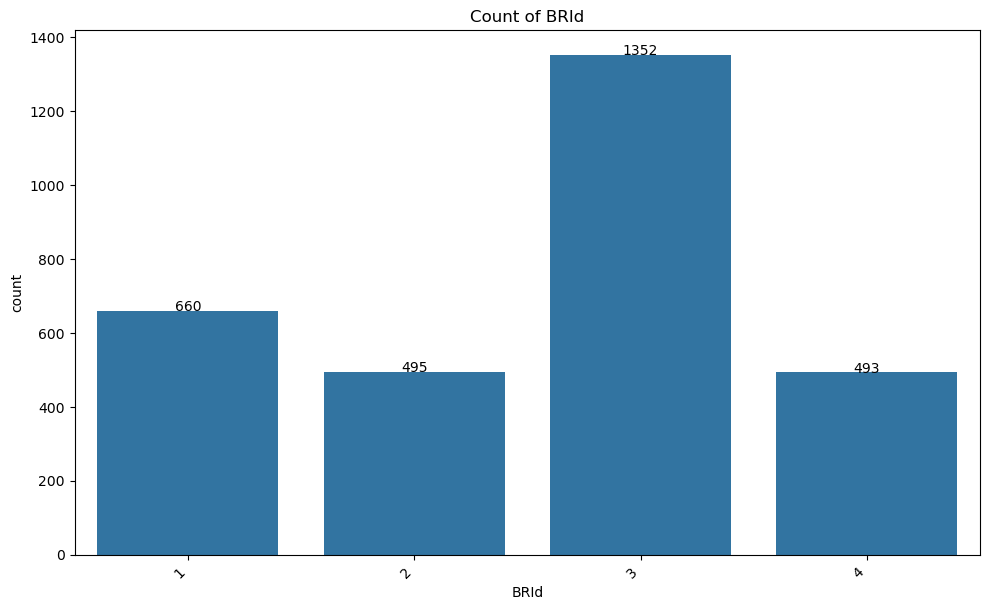

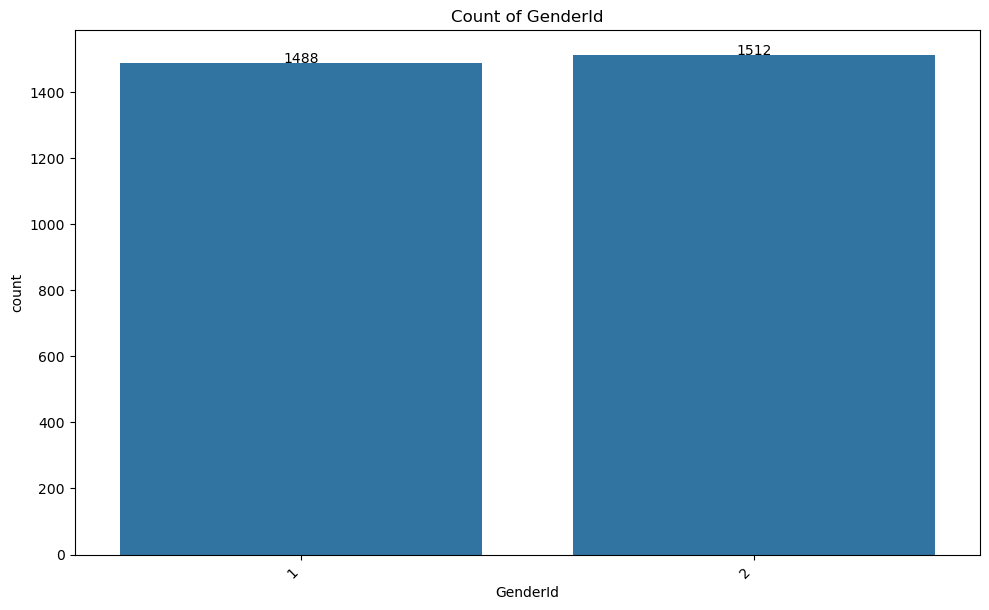

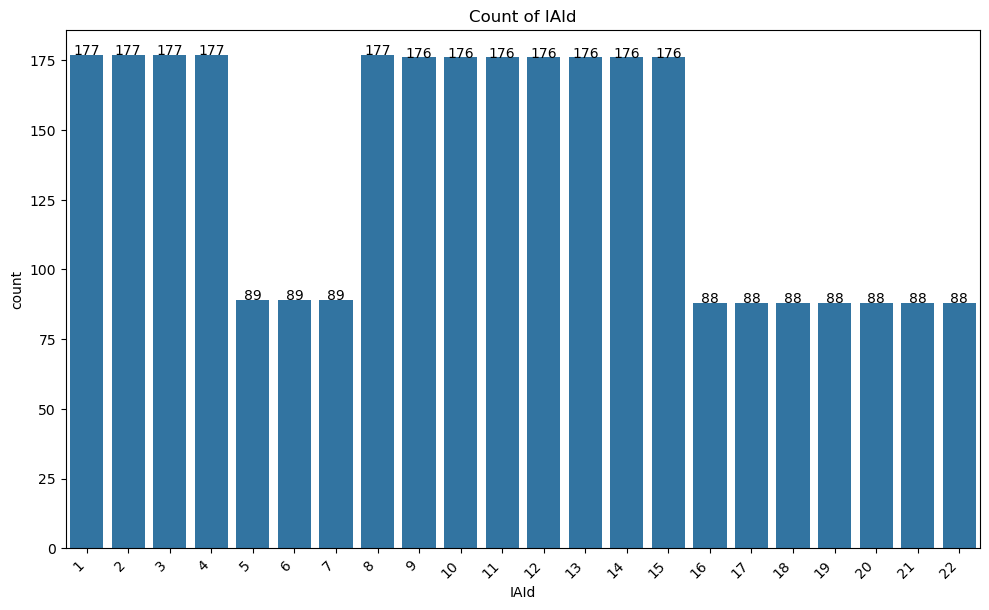

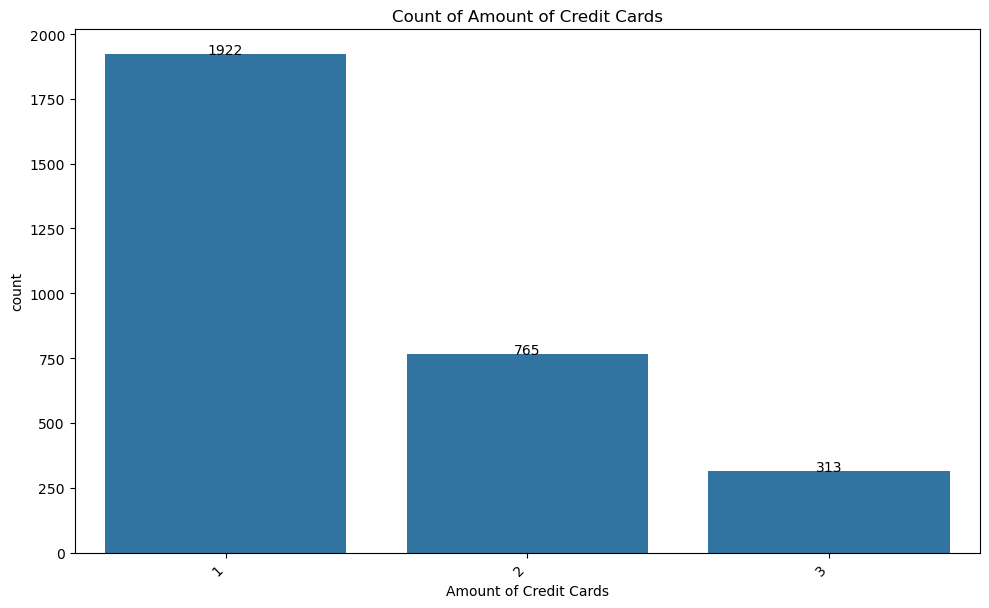

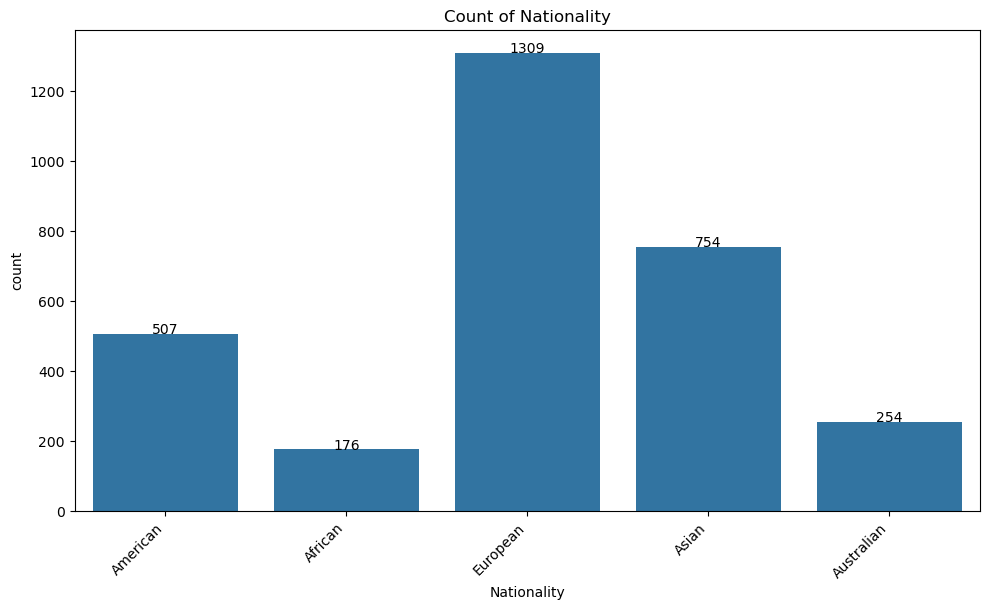

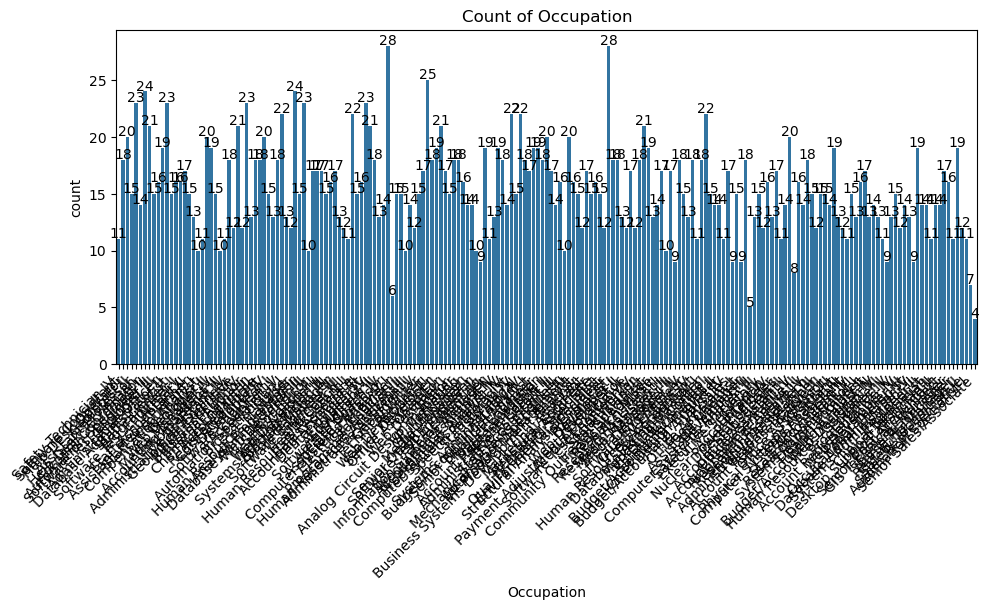

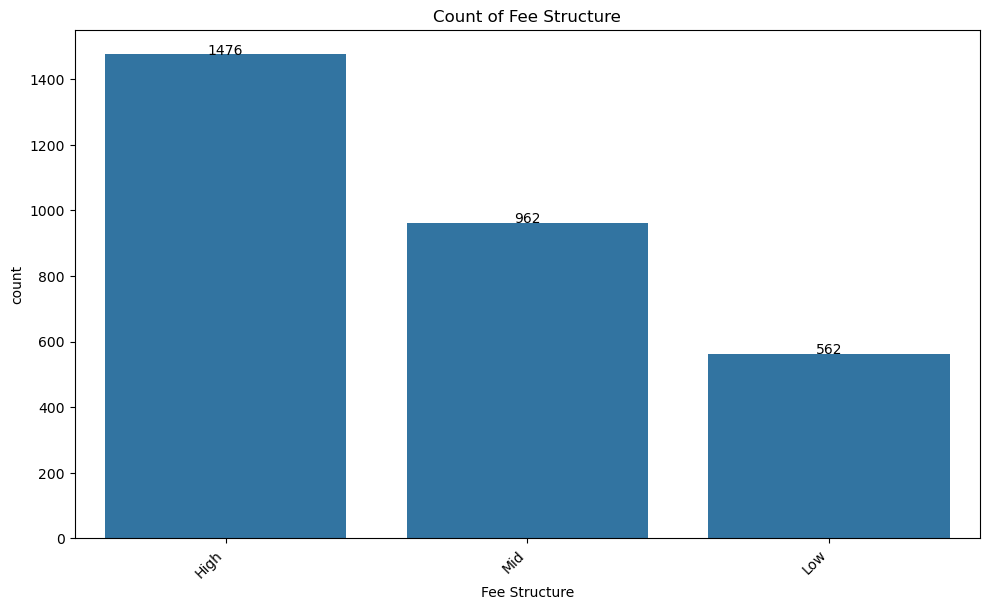

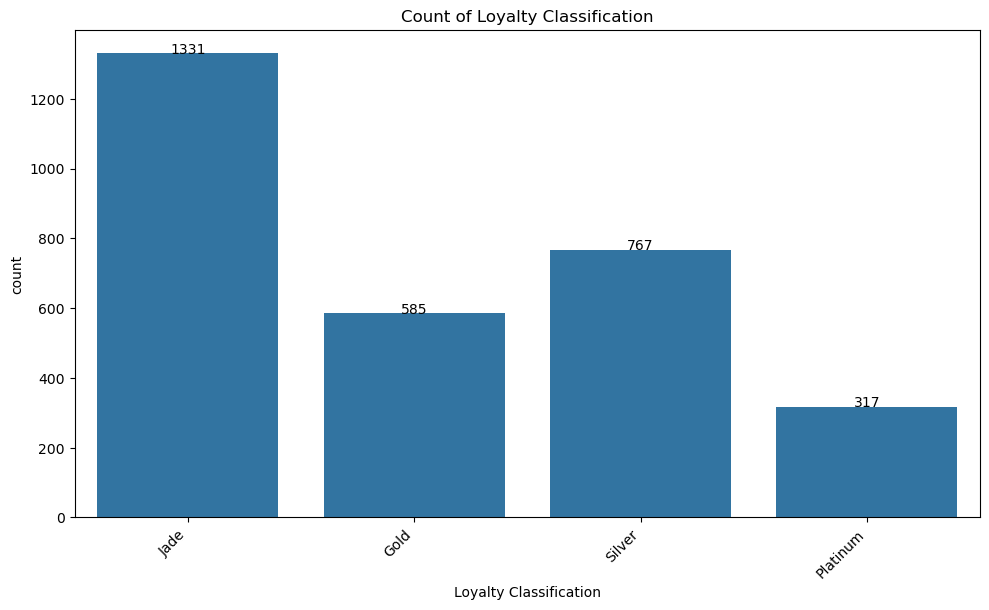

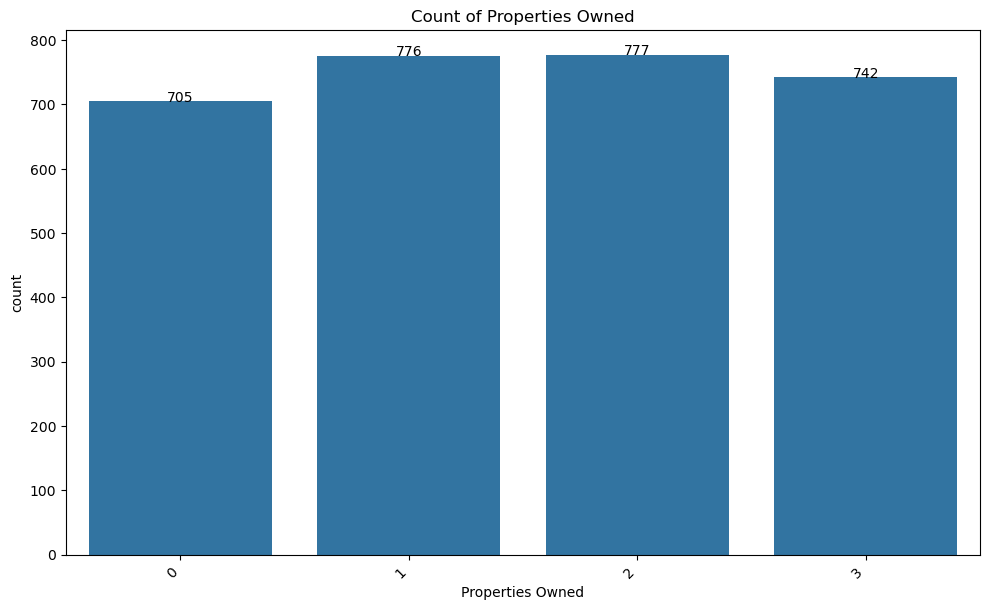

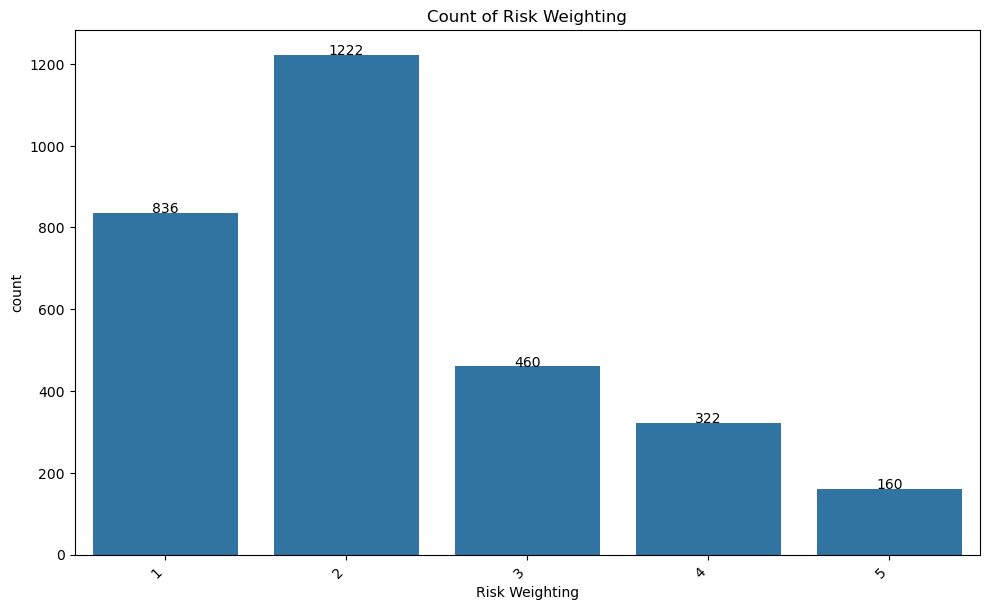

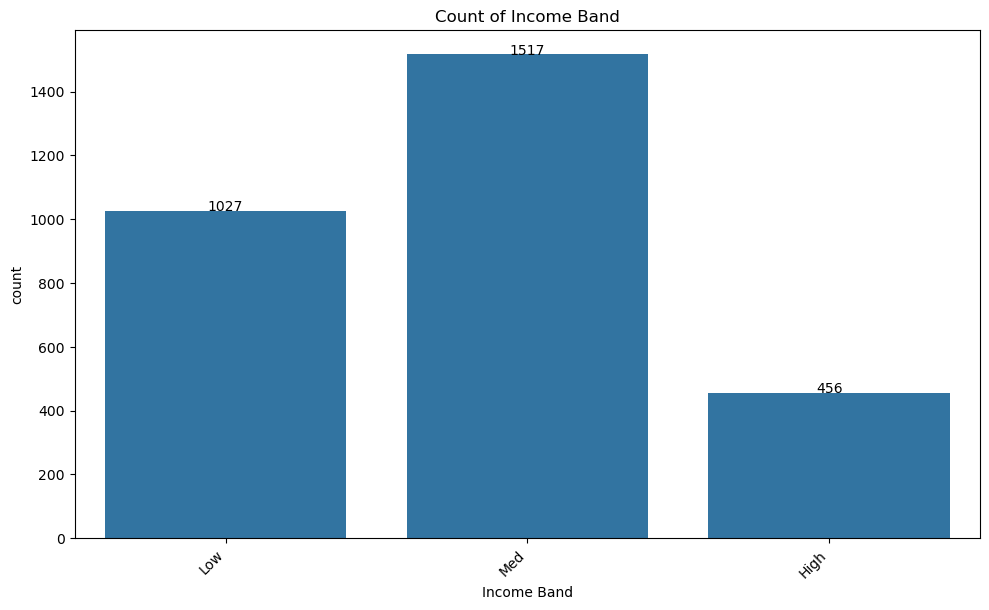

In [32]:
for i, predictor in enumerate(df[["BRId", "GenderId", "IAId", "Amount of Credit Cards", "Nationality", 
                                 "Occupation", "Fee Structure", "Loyalty Classification", 
                                 "Properties Owned", "Risk Weighting", "Income Band"]].columns):
    plt.figure(figsize=(10, 6))  # Set figure size for better visibility
    
    # Create the countplot
    ax = sns.countplot(data=df, x=predictor)
    
    # Add data labels on top of each bar
    for p in ax.patches:
        height = p.get_height()
        ax.text(
            p.get_x() + p.get_width()/2.,  # x position: center of the bar
            height + 0.1,                   # y position: slightly above the bar
            f'{int(height)}',               # text: count value as integer
            ha="center",                    # horizontal alignment: centered
            fontsize=10                     # font size
        )
    
    # Improve readability for x-axis labels if needed
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()  # Adjust layout to prevent label cutoff
    
    plt.title(f'Count of {predictor}')
    plt.show()

BIVARIATE ANALYSIS

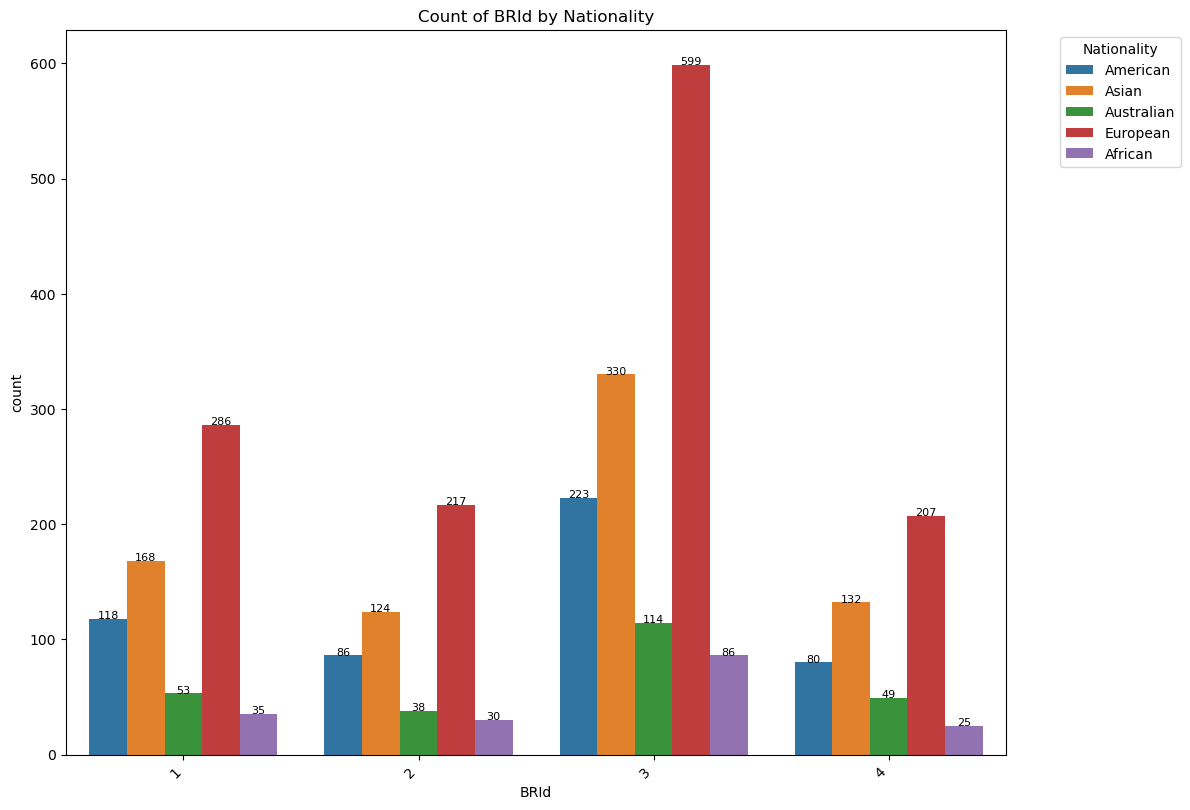

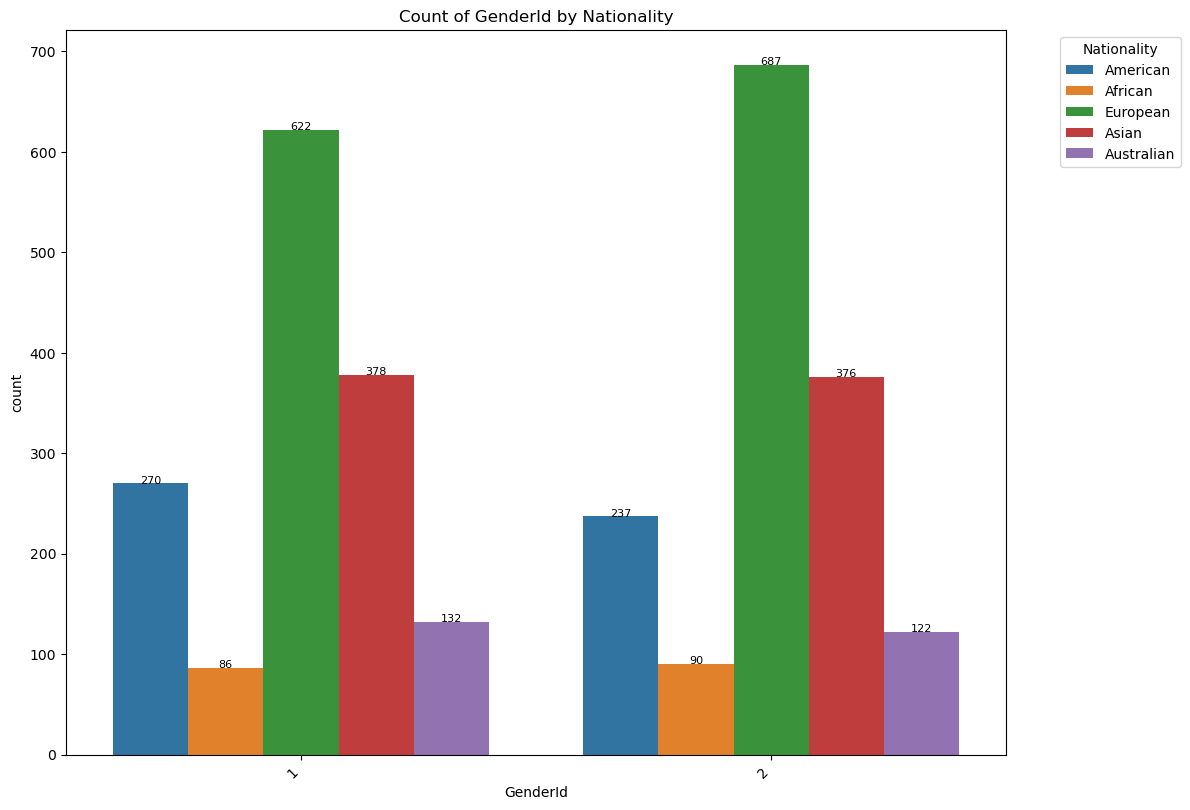

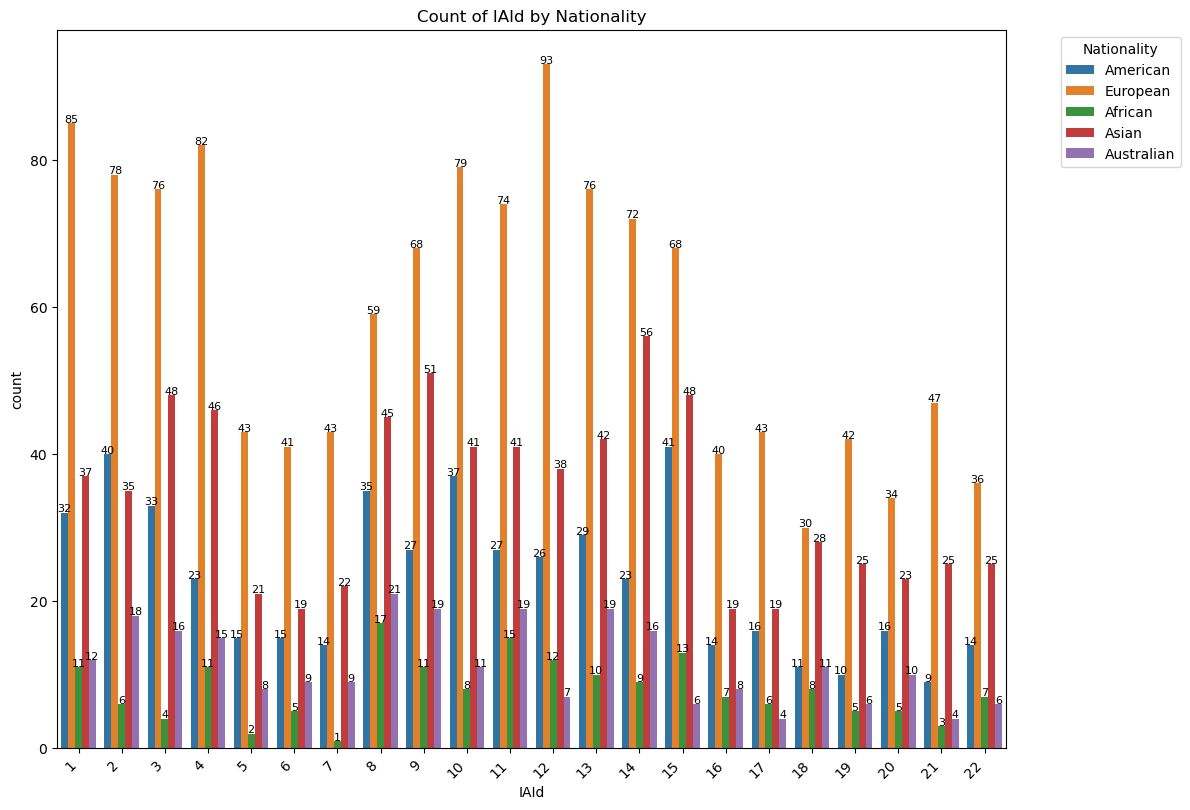

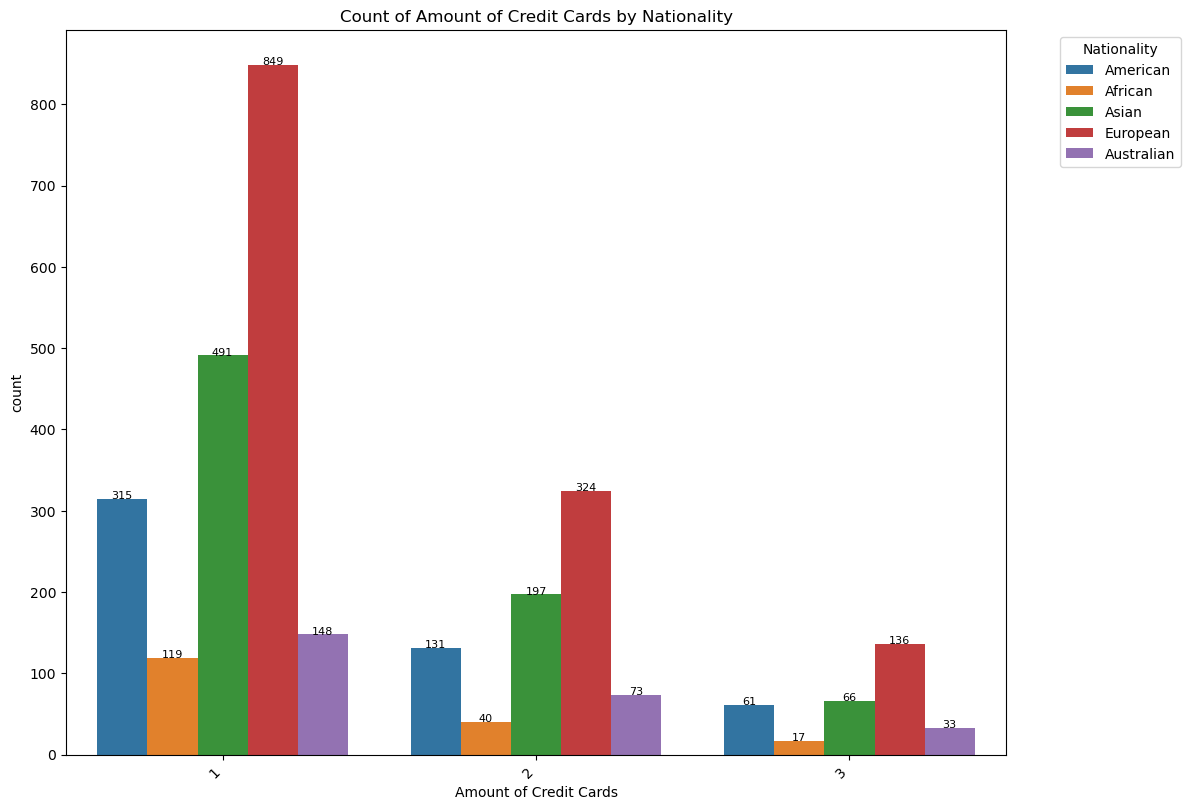

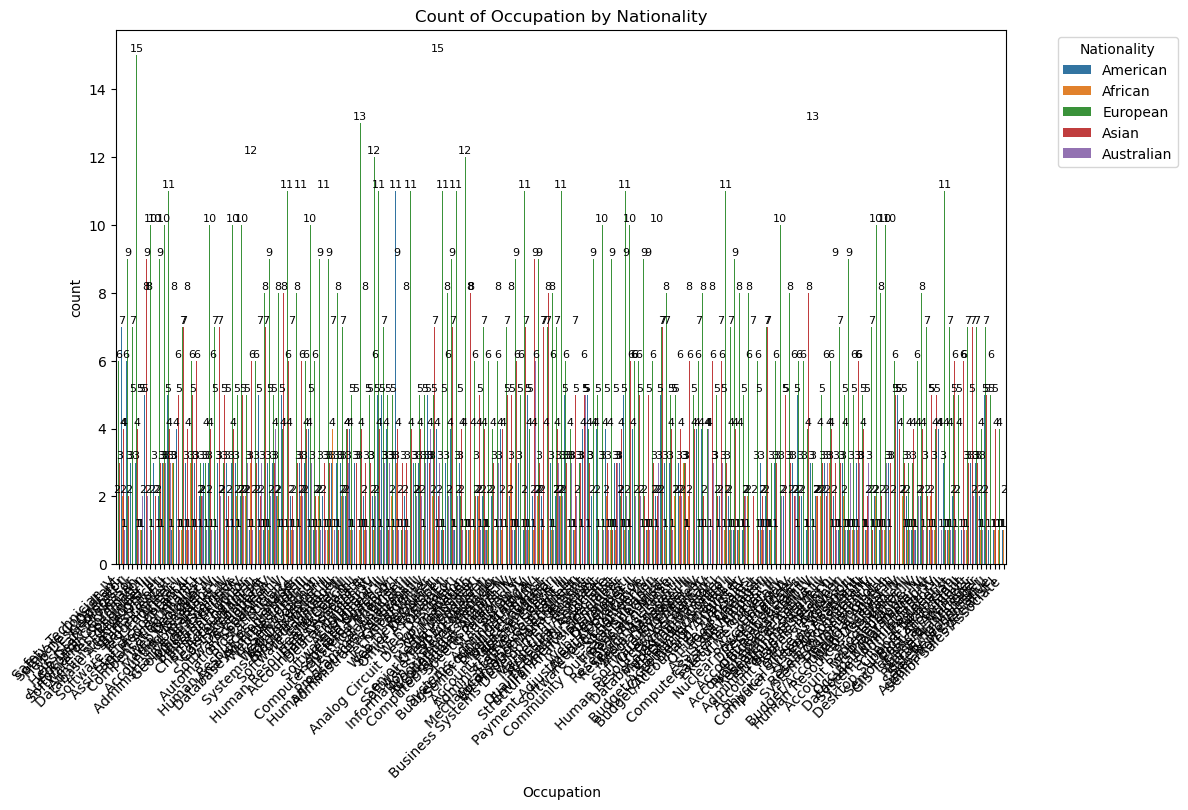

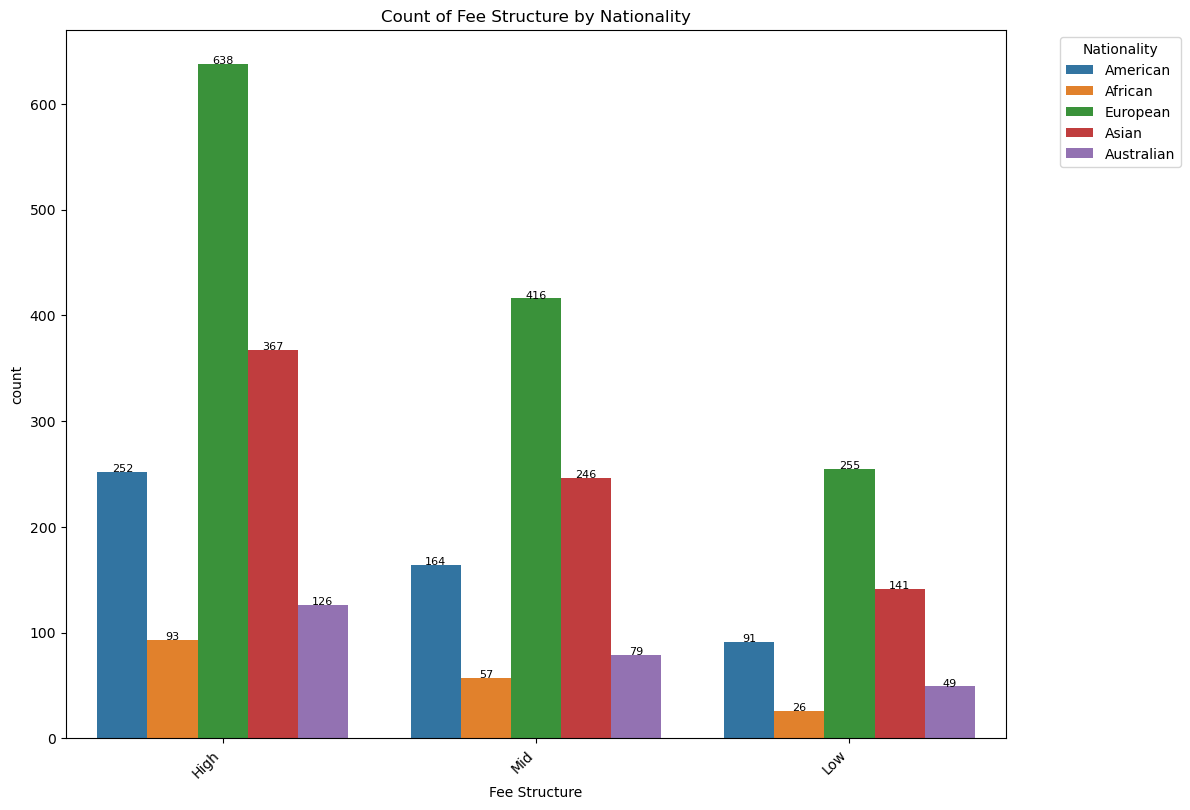

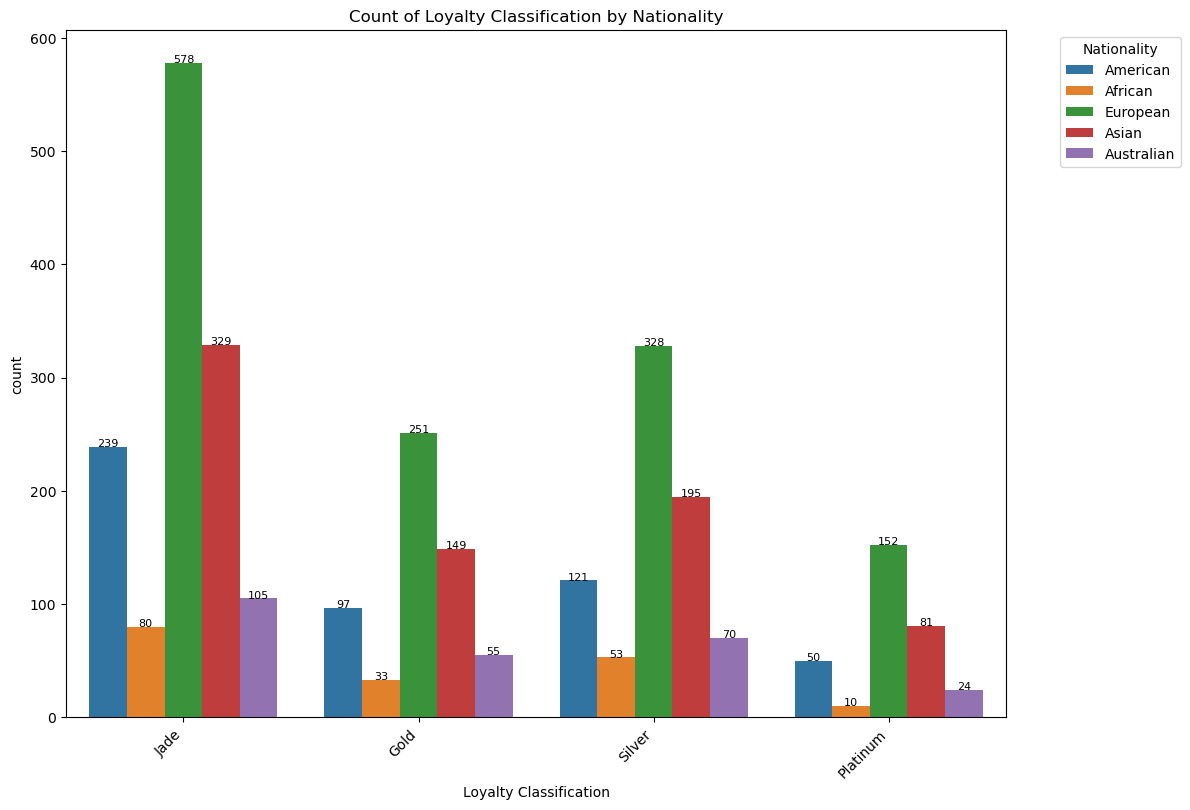

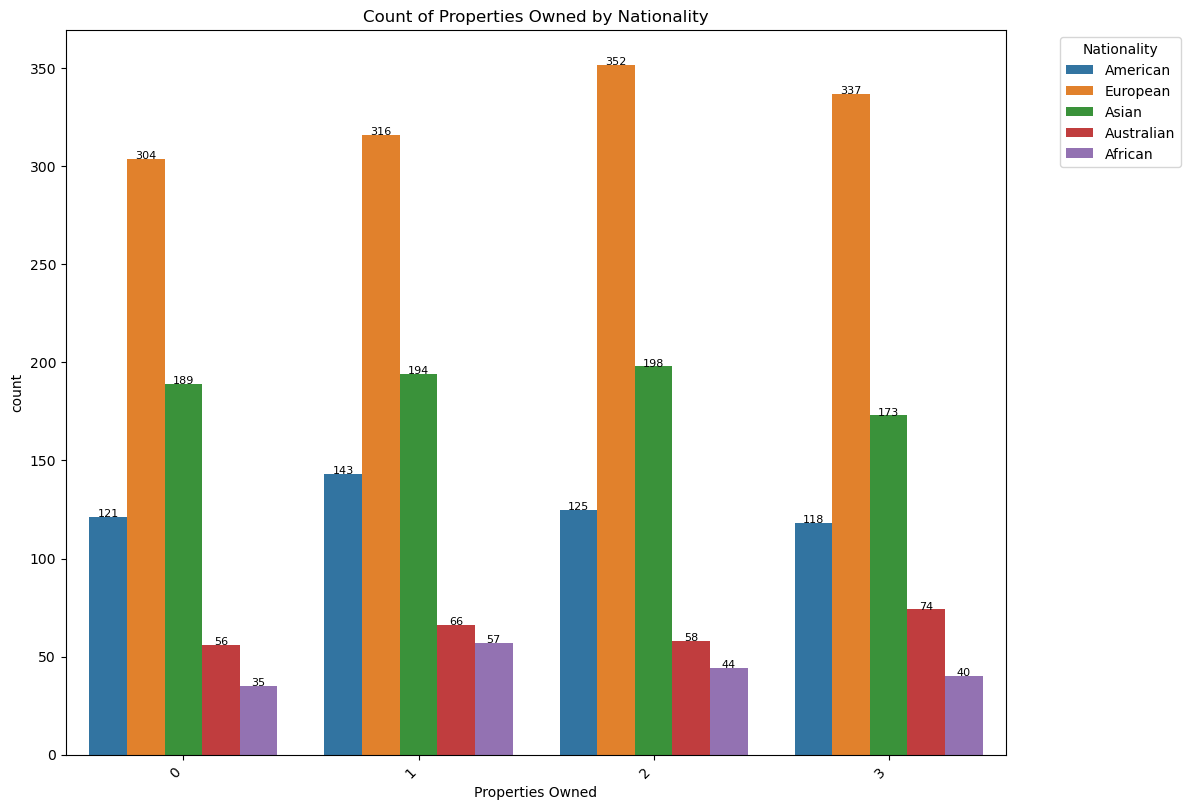

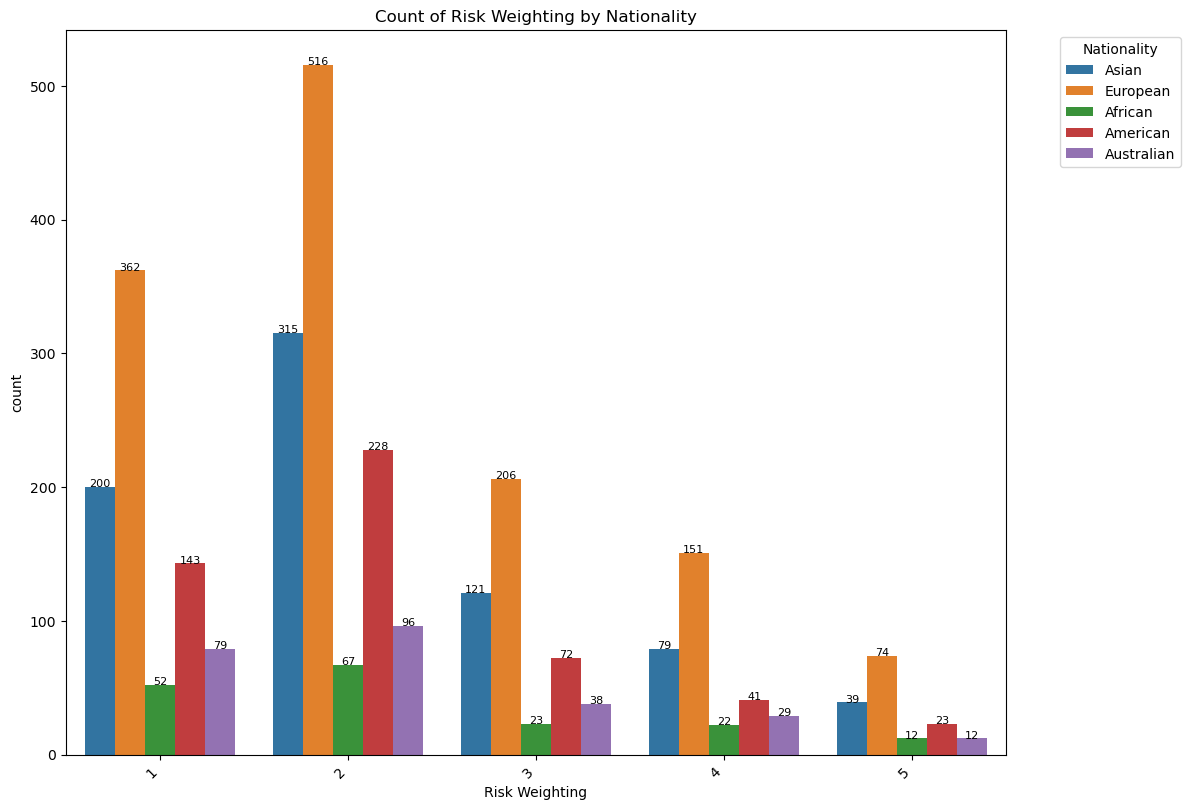

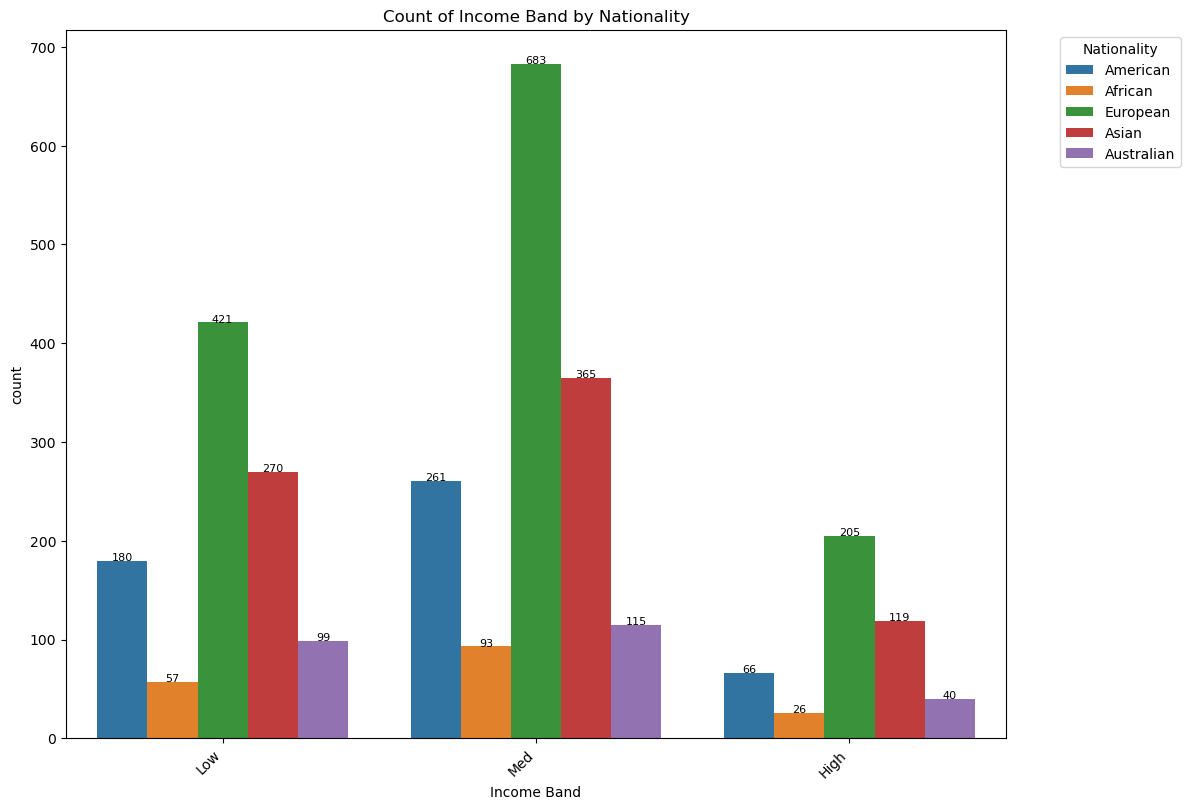

In [33]:
for i, predictor in enumerate(df[["BRId", "GenderId", "IAId", "Amount of Credit Cards", "Nationality", 
                                 "Occupation", "Fee Structure", "Loyalty Classification", 
                                 "Properties Owned", "Risk Weighting", "Income Band"]].columns):
    # Skip if the predictor is Nationality (to avoid using it as both x and hue)
    if predictor == 'Nationality':
        continue
        
    plt.figure(figsize=(12, 8))  # Larger figure for grouped bars
    
    # Create the countplot with hue
    ax = sns.countplot(data=df, x=predictor, hue='Nationality')
    
    # Add data labels on top of each bar
    for p in ax.patches:
        height = p.get_height()
        # Only add labels for bars with non-zero height
        if height > 0:
            ax.text(
                p.get_x() + p.get_width()/2.,  # x position: center of the bar
                height + 0.1,                   # y position: slightly above the bar
                f'{int(height)}',               # text: count value as integer
                ha="center",                    # horizontal alignment: centered
                fontsize=8,                     # smaller font size for grouped bars
                rotation=0                      # vertical text for narrow bars
            )
    
    # Improve readability
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Nationality', bbox_to_anchor=(1.05, 1), loc='upper left')  # Move legend outside
    plt.tight_layout()  # Adjust layout to prevent label cutoff
    
    plt.title(f'Count of {predictor} by Nationality')
    plt.show()

NUMERICAL ANALYSIS

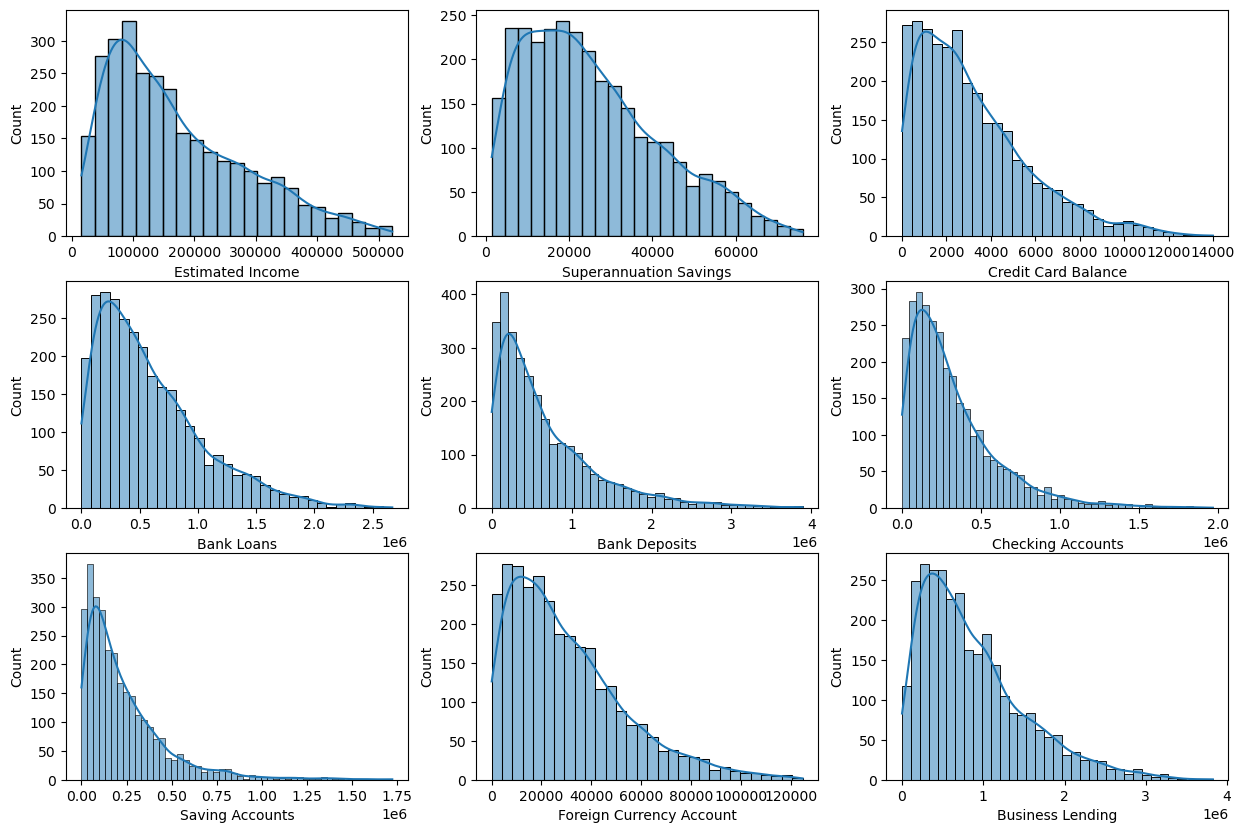

In [35]:
numerical_cols = ['Estimated Income', 'Superannuation Savings', 'Credit Card Balance', 'Bank Loans', 'Bank Deposits', 'Checking Accounts', 'Saving Accounts', 'Foreign Currency Account', 'Business Lending']

# Univariate analysis and visualization
plt.figure(figsize=(15,10))
for i,col in enumerate(numerical_cols):
  plt.subplot(3,3,i+1)
  sns.histplot(df[col],kde=True)
plt.show()

HEATMAP

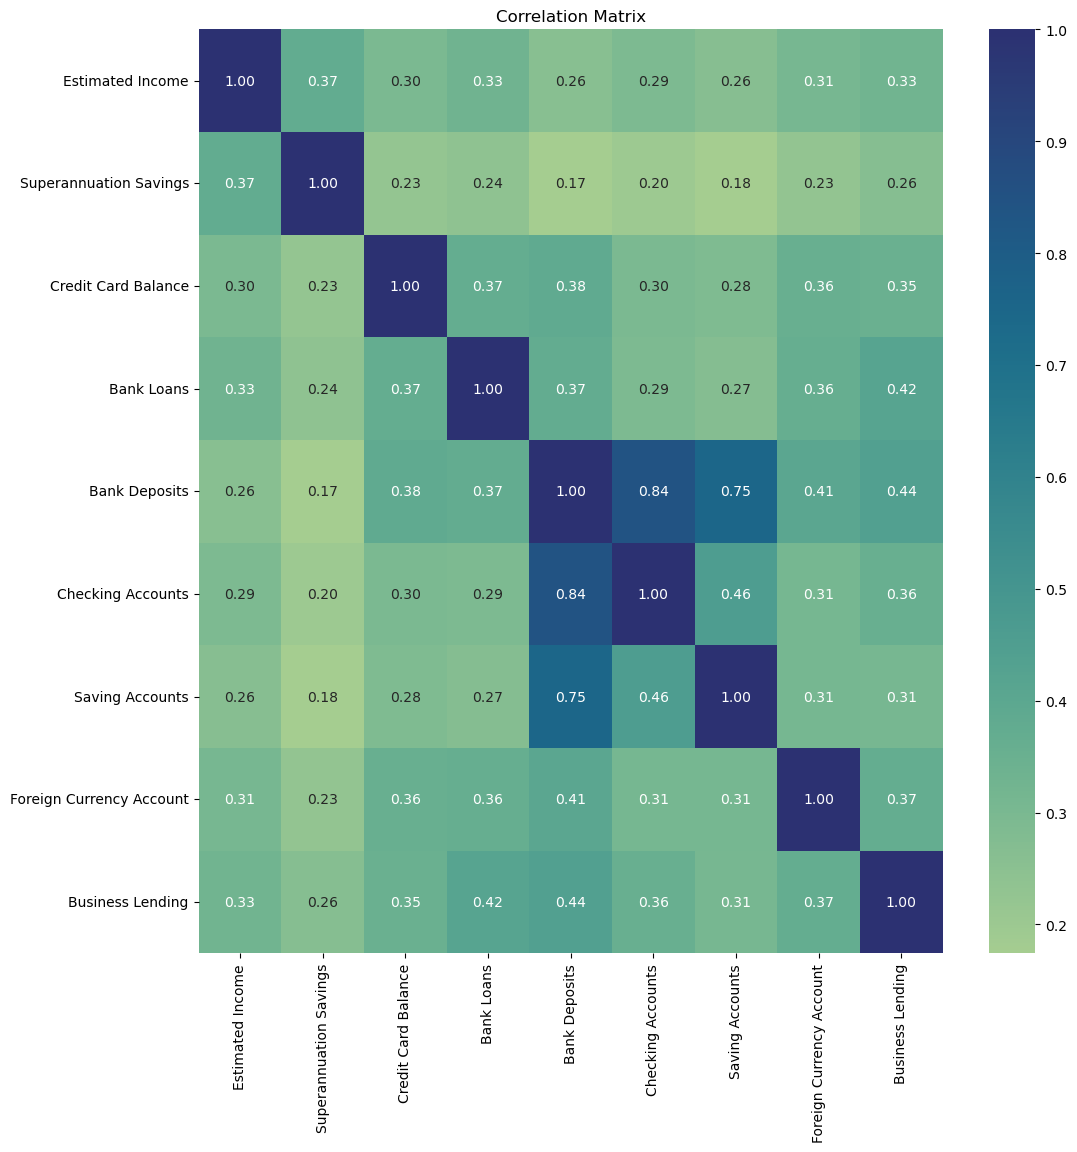

In [36]:
#Correlation betweeen numerical attributes 
numerical_cols = ['Estimated Income', 'Superannuation Savings', 'Credit Card Balance', 'Bank Loans', 'Bank Deposits', 'Checking Accounts', 'Saving Accounts', 'Foreign Currency Account', 'Business Lending']

correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12,12))
sns.heatmap(correlation_matrix, annot=True, cmap='crest', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()